
# Laboratorium 6: Segmentacja 3D (MRI) — architektura typu V-Net


W tym ćwiczeniu również zajmiemy się problemem **segmentacji semantycznej** obszarów hipokampu, lecz tym razem dla danych trójwymiarowych za pomocą architektury typu **V-Net**.

**Cele zajęć**
- Wczytanie danych trójwymiarowych i sprawdzenie ich formatu.
- Wykorzystanie **MONAI** do wczytywania i przetwarzania wstępnego danych 3D.
- Trening sieci za pomocą losowych voxeli 3D.
- Poznanie architektury typu **V-Net** oraz czym różni się od **U-Net**.
- Wykonanie segmentacji danych trójwymiarowych oraz sprawdzenie skuteczności rozwiązania.

**Dataset:**  
Użyjemy **MSD Task04 Hippocampus** — zbioru MRI z adnotacjami hipokampa pochodzącego z Medical Segmentation Decathlon. Zawiera on około ~260 skanów z maskami (etykiety: 0 = tło, 1 = anterior hippocampus, 2 = posterior hippocampus). Dane zostaną automatycznie pobrane przez MONAI (`DecathlonDataset`). W notebooku dodatkowo przeprowadzamy: izotropizację do 1×1×1 mm, normalizację intensywności, oraz ekstrakcję 3D‑patchy z kontrolowanym stosunkiem próbek pozytywnych/negatywnych.

## 0) Instalacja i importy

Jeśli chcemy powtarzalnych wyników możemy ustawić stały SEED.

In [3]:

# !uv pip -q install monai-weekly pytorch-lightning torchmetrics nibabel scikit-image --extra-index-url https://download.pytorch.org/whl/cpu

import os, tarfile, urllib.request, random, glob, math, json
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch, torch.nn as nn, torch.nn.functional as F
# from torch.utils.data import DataLoader
from monai.data import DataLoader


from monai.apps import download_and_extract
from monai.data import CacheDataset, Dataset, decollate_batch, list_data_collate
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, RandSpatialCropd, RandCropByPosNegLabeld,
    RandFlipd, RandRotate90d, EnsureTyped, EnsureType, AsDiscrete,
    CenterSpatialCropd
)
from monai.networks.nets import VNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

from monai.apps import DecathlonDataset
from pathlib import Path
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd, NormalizeIntensityd, RandCropByPosNegLabeld, RandFlipd, RandRotate90d, EnsureTyped, CenterSpatialCropd, SpatialPadd

import pytorch_lightning as pl
from pytorch_lightning import LightningModule, LightningDataModule, Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

from torchmetrics.classification import MulticlassJaccardIndex

# SEED = 42
SEED = None
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

if SEED is not None:
    set_seed()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device, '| Lightning:', pl.__version__)


Device: cpu | Lightning: 2.5.5


## Zadanie 1 – Konfiguracja parametrów, pobranie danych i przetwarzanie wstępne

W tym zadaniu przygotujemy dane uczące i walidacyjne wykorzystując funkcje i transformacje z biblioteki MONAI. Parametry zostały już zdefiniowane w komórce z kodem poniżej. 4 pierwsze parametry są oczywiste, natomiast warto wyjaśnić znaczenie drugiej połowy.
- `ROI_SIZE` - rozmiar wycinanych patchy 3D. Zamiast przetwarzać całą pojedynczą próbkę danych, dla trójwymiarowych częstym podejściem jest wycinanie z nich fragmentu (ROI) o zadanym rozmiarze i traktowanie tego ROI jako pojedynczej próbki.
- `SAMPLES_PER_VOLUME` — liczba patchy pobieranych z jednego wolumenu uczącego dla każdej próbki w każdej epoce treningu. Zwiększenie wartości generuje więcej przykładów treningowych z każdego skanu (więcej wariancji), ale też zwiększa czas przetwarzania.
- `POS_NEG_RATIO` — stosunek patchy wokół "piksela" pozytywnego (o masce większej od 0) do patchy wokół "piksela" negatywnego (należącego do tła) wybranych dla każdego przykładu treningowego. Przy małych obiektach (np. hipokamp) losowe ROI ma małe szanse trafić na obiekt, więc takie losowanie pozwala lepiej nauczyć model rozpoznawania struktur zamiast przeuczenia na tle.
- `BATCH_SIZE` — liczba próbek w batchu podczas treningu (jak we wcześniejszych ćwiczeniach). Jednak tutaj ten parametr należy rozważać wspólnie z `SAMPLES_PER_VOLUME`. Najpierw wybierane jest `BATCH_SIZE` próbek ze zbioru danych, a następnie z każdej pobranej próbki pobierane jest `SAMPLES_PER_VOLUME` patchy o rozmiarze `ROI_SIZE`.

Dlaczego stosujemy wycinanie patchy i opisane transformacje?
- Efektywność pamięci i obliczeń: przetwarzanie pełnych wolumenów 3D jest zwykle bardzo kosztowne (pamięć GPU), dlatego uczymy na mniejszych patch'ach. Jest to szczególnie ważne dla zbiorów o dużych rozdzielczościach.
- Zwiększenie liczby próbek: z jednego wolumenu możemy uzyskać wiele niezależnych patchy, co pomaga w trenowaniu (więcej różnych widoków/położeń struktury).
- Radzenie sobie z nierównomiernym rozkładem klas: przez kontrolę pos/neg można wymusić, żeby model widywał wystarczająco dużo przykładów rzadkich klas.
- Możliwość wykonywania obliczeń dla danych wejściowych o różnych rozmiarach.

Należy również zauważyć, że wykorzystywany dataset ma tylko dwa podzbiory: treningowy i walidacyjny. Można ten problem rozwiązać na 2 sposoby. Pierwszym jest traktowanie zbioru walidacyjnego zarówno jako zbiór testowy. Drugim jest wydzielenie zbioru testowego ze zbioru walidacyjnego. W naszym rozwiązaniu wykorzystamy to pierwsze podejście.

1. Zdefinujmy 3 listy transformacji: `pre_transforms`, `train_transforms` i `val_transforms`.
2. `pre_transforms` jest listą, która zawiera początkowe przekształcenia, wykonywane są dla wszystkich wczytywanych danych:
   - `LoadImaged(keys=["image", "label"])` - wczytuje dane w formacie 'NIfTI' oraz odpowiadającą im maskę segmentacji,
   - `EnsureChannelFirstd(keys=["image", "label"])` - zapewnienie że kanał jest pierwszym wymiarem,
   - `Orientationd(keys=["image", "label"], axcodes="RAS")` - orientacja do standardowego układu RAS (Right-Anterior-Superior),
   - `Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest"))` - izotropizacja voxeli do 1×1×1 mm, odpowiednio metodą biliniową dla danych uczących i metodą najbliższego sąsiada dla maski segmentacji,
   - `NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True)` - normalizacja intensywności MRI
3. Stwórz `train_transforms` za pomocą funkcji `Compose`, której argumentem jest lista transformacji. Na jej początku znajdować się powinny elementy z `pre_transforms`, a następnie dodatkowe augmentacje:
   - `RandCropByPosNegLabeld` - losowe wycinanie patchy 3D z kontrolą pos/neg (parametry: `keys=["image", "label"]`, `image_key="image`, `label_key="label"`, `spatial_size` (rozmiar patch'y), `pos` (część patch'y wokół pikseli pozytywnych), `neg` (część patchy wokół pikseli negatywnych), `num_samples` (liczba patch'y dla każdej próbki)),
   - `RandFlipd` x2 - losowe odbicie z zadanym prawdopodobieństwem `prob` dla osi `spatial_axis` 1 i 2,
   - `EnsureTyped(keys=["image", "label"])` - konwersja do tensorów.
4. Stwórz `val_transforms` podobnie jak `train_transform` bez augmentacji. Do `pre_transforms` dodaj tylko:
   - `CenterSpatialCropd(keys=["image", "label"], roi_size=ROI_SIZE)` - wycinanie środkowego patcha. Dla walidacyjnego nie powinno być losowo wybieranych patchy, żeby osiągnąć spójne porównanie pomiędzy epokami.
   - `EnsureTyped(keys=["image", "label"])`.
5. Pobierz i przygotuj zbiory używając `DecathlonDataset` (już w kodzie poniżej). Aby zmniejszyć wykorzystanie pamięci RAM możesz zmniejszyć parametr `cache_rate`. Oznacza on ilość danych, która po przetwarzaniu wstępnym zostanie zapamiętana w pamięci RAM.
6. Wyświetl liczbę próbek w każdym zbiorze.

In [7]:
# Poprawione parametry - zmniejszamy ROI_SIZE
ROI_SIZE = (32, 32, 32)  # Zmniejszone z (64, 64, 64)
SAMPLES_PER_VOLUME = 4
POS_NEG_RATIO = 1.0
BATCH_SIZE = 2

# Definicja transformacji z dodaniem paddingu
pre_transforms = [
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    SpatialPadd(keys=["image", "label"], spatial_size=ROI_SIZE)  # Dodany padding
]

train_transforms = Compose(pre_transforms + [
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=ROI_SIZE,
        pos=POS_NEG_RATIO,
        neg=1.0,
        num_samples=SAMPLES_PER_VOLUME
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    EnsureTyped(keys=["image", "label"])
])

val_transforms = Compose(pre_transforms + [
    CenterSpatialCropd(keys=["image", "label"], roi_size=ROI_SIZE),
    EnsureTyped(keys=["image", "label"])
])

# Pobieranie i przygotowanie danych
train_ds = DecathlonDataset(
    root_dir="data",
    task="Task04_Hippocampus",
    section="training",
    transform=train_transforms,
    download=True,
    cache_rate=1.0
)

val_ds = DecathlonDataset(
    root_dir="data",
    task="Task04_Hippocampus",
    section="validation",
    transform=val_transforms,
    download=True,
    cache_rate=1.0
)

print(f"Liczba próbek treningowych: {len(train_ds)}")
print(f"Liczba próbek walidacyjnych: {len(val_ds)}")

2025-11-07 17:11:13,869 - INFO - Verified 'Task04_Hippocampus.tar', md5: 9d24dba78a72977dbd1d2e110310f31b.
2025-11-07 17:11:13,870 - INFO - File exists: data/Task04_Hippocampus.tar, skipped downloading.
2025-11-07 17:11:13,870 - INFO - Non-empty folder exists in data/Task04_Hippocampus, skipped extracting.


Loading dataset: 100%|██████████| 208/208 [00:01<00:00, 190.86it/s]


2025-11-07 17:11:15,642 - INFO - Verified 'Task04_Hippocampus.tar', md5: 9d24dba78a72977dbd1d2e110310f31b.
2025-11-07 17:11:15,642 - INFO - File exists: data/Task04_Hippocampus.tar, skipped downloading.
2025-11-07 17:11:15,642 - INFO - Non-empty folder exists in data/Task04_Hippocampus, skipped extracting.


Loading dataset: 100%|██████████| 52/52 [00:00<00:00, 180.66it/s]

Liczba próbek treningowych: 208
Liczba próbek walidacyjnych: 52


## Zadanie 2 – Implementacja LightningDataModule

W tym zadaniu stworzymy klasę organizującą dostęp do danych zgodnie z konwencją PyTorch Lightning.

1. Zaimplementuj klasę `HippoMonaiDataModule`, która dziedziczy po `pl.LightningDataModule`.
2. Zaimplementuj metodę `__init__` z parametrami: `train_ds`, `val_ds`, `test_ds`, `batch_size`, `num_workers`.
3. Wywołaj konstruktor klasy bazowej: `super().__init__()`.
4. Zapamiętaj wszystkie argumenty.
5. Zaimplementuj metodę `train_dataloader`, która zwraca `DataLoader` dla zbioru treningowego.
6. Zaimplementuj metodę `val_dataloader` analogicznie, ale bez mieszania danych.
7. `test_dataloader` w tym przypadku wskazuje na ten sam zbiór co `val_dataloader`.
8. Stwórz instancję przygotowanej klasy.
9. Pobierz jeden batch z train dataloadera: `b = next(iter(dm.train_dataloader()))`, a następnie sprawdź jego rozmiar. W tym celu wykorzystaj `b["image"]` i `b["label"]`.
10. Zwróć uwagę na wielkość batch'a i czy zgadza się z przewidywaniami.

In [8]:
class HippoMonaiDataModule(pl.LightningDataModule):
    def __init__(self, train_ds, val_ds, test_ds=None, batch_size=2, num_workers=0):
        super().__init__()
        self.train_ds = train_ds
        self.val_ds = val_ds
        self.test_ds = test_ds if test_ds is not None else val_ds
        self.batch_size = batch_size
        self.num_workers = num_workers

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            collate_fn=list_data_collate
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=list_data_collate
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=list_data_collate
        )

# Tworzenie instancji DataModule
dm = HippoMonaiDataModule(
    train_ds=train_ds,
    val_ds=val_ds,
    batch_size=BATCH_SIZE,
    num_workers=0
)

# Sprawdzenie batcha
b = next(iter(dm.train_dataloader()))
print("Shape of image batch:", b["image"].shape)
print("Shape of label batch:", b["label"].shape)
print("Data type of image:", b["image"].dtype)
print("Data type of label:", b["label"].dtype)
print("Number of samples in batch:", b["image"].shape[0])

Shape of image batch: torch.Size([8, 1, 32, 32, 32])
Shape of label batch: torch.Size([8, 1, 32, 32, 32])
Data type of image: torch.float32
Data type of label: torch.float32
Number of samples in batch: 8


## Zadanie 3 – Implementacja V-Net

W tym zadaniu stworzymy architekturę sieci typu V-Net oraz metody potrzebne do jej treningu.

**Część A: Implementacja architektury**

1. Zaimplementuj klasę `ConvBlock3d`, która dziedziczy po `nn.Module`:
   - Konstruktor przyjmuje liczbę kanałów wejściowych i wyjściowych, rozmiar konwolucji, stride i padding.
   - Definiuje: `self.conv` (`nn.Conv3d` bez bias), `self.bn` (`nn.BatchNorm3d`) i funkcję aktywacji (`nn.PReLU`). PReLU różni się od ReLU tym, że zamiast całkowicie zerować wartości ujemne, przepuszcza ich część z uczalnym współczynnikiem α, dzięki czemu neurony rzadziej „umierają”.
   - Metoda `forward` przepuszcza dane wejściowe po kolei przez konwolucję, normalizację, a następnie funkcję aktywacji.

2. Zaimplementuj klasę `UpConvBlock3d`, która dziedziczy po `nn.Module`:
   - Jest ona symetryczna do klasy `ConvBlock3d`, lecz zamiast `nn.Conv3d` stosujemy `nn.ConvTranspose3d`.

3. Zaimplementuj klasę `ResidualBlock3d`, która dziedziczy po `nn.Module`:
   - Konstruktor przyjmuje liczbę kanałów (nie zmienia się ona w tym bloku) i liczbę bloków konwolucyjnych konwolucji.
   - Stwórz listę kolejnych warstw w tym bloku. Pojedynczy element składa się z `nn.Conv3d` (rozmiar konwolucji 3, padding 1), `nn.BatchNorm3d` i `nn.PReLU`. Ich liczba zależna jest od przekazanego parametru.
   - Połącz warstwy z listy za pomocą `nn.Sequential`.
   - W metodzie `forward przepuść dane wejściowe przez zdefiniowany blok. Dodatkowo dodajemy połączenie rezydualne, czyli do wyjścia dodajemy wejście do sieci (nie zmieniamy rozmiaru przestrzennego i liczby warstw, więc rozmiary powinny się zgadzać).

3. Zaimplementuj klasę `VNet3D`, która dziedziczy po `nn.Module`:
   - Konstruktor przyjmuje liczbę kanałów wejściowych, liczbę klas i bazową liczbę kanałów w kolejnych warstwach.
   - **Enkoder:**
     - Składa się on z na zmianę połączonych warstw `ConvBlock3d` i `ResidualBlock3d`. Pierwsza para nie zmniejsza rozdzielczości przestrzennej, tylko zwiększa liczbę kanałów do bazowej.
     - W kolejnych parach rozdzielczość przestrzenna jest zmniejszana przez zastosowanie stride równego 2 w `ConvBlock3d`, natomiast liczba kanałów zwiększana jest dwukrotnie.
     - W kolejnych parach rośnie również liczba bloków w warstwach `ResidualBlock3d`.
     - Stosujemy konwolucje o rozmiarze 3 i padding'u równym 1.
   - **Dekoder:**
     - Składa się on z na zmianę połączonych warstw `UpConvBlock3d` i `ResidualBlock3d`.
     - W kolejnych parach rozdzielczość przestrzenna jest zwiększana, natomiast liczba kanałów jest zmniejszana.
     - Zmniejsza się również liczba bloków w warstwach `ResidualBlock3d` dla kolejnych par.
     - W blokach `UpConvBlock3d` stosujemy konwolucje o rozmiarze 2, stride równym 2, a padding równym 0.
     - Na koniec liczbę kanałów zmniejszamy do liczby klas za pomocą `nn.Conv3d` o rozmiarze 1.
   - Metoda `forward`:
     - Najpierw przepuszczamy dane wejściowe przez kolejne warstwy enkodera.
     - Dla dekodera musimy dodać również połączenia z enkodera.
     - Zamiasat konkatenacji kanałów w V-Net stosujemy dodawanie.
     - Dla wyjścia z każdego bloku `UpConvBlock3d` dodajemy wyjście z odpowiadającego bloku `ConvBlock3d` w enkoderze.

**Część B: Implementacja treningu**

1. Zaimplementuj klasę `LitVNet`, która dziedziczy po `LightningModule`:
   - Konstruktor przyjmuje liczbę kanałów wejściowych, liczbę klas i learning rate.
   - Wywołaj `super().__init__()` oraz `self.save_hyperparameters()`
   - Stwórz instancję zaimplementowanej wcześniej sieci.
   - Zdefiniuj funkcję straty `DiceCELoss(to_onehot_y=True, softmax=True, squared_pred=False, include_background=True, lambda_dice=1.0, lambda_ce=1.0)`
   - Zdefiniuj metryki:
     - Dice: `DiceMetric(include_background=True, reduction="mean", get_not_nans=False)`
     - IoU: `MulticlassJaccardIndex(num_classes=out_channels, average="macro")`

2. Zaimplementuj metodę `forward(self, x)` zwracającą wyjście sieci.

6. Zaimplementuj metodę `configure_optimizers`:
   - Pptymalizator Adam: `torch.optim.Adam(self.parameters(), lr=self.hparams.lr)`
   - Scheduler cosinusowy: `torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)`
   - Zwróć słownik: `{"optimizer": opt, "lr_scheduler": sch}`

7. Zaimplementuj metody `training_step`, `validation_step` i `test_step`:
   - Pobierz dane: `batch["image"]` `batch["label"].long()`.
   - Oblicz predykcje: `self(x)`.
   - Oblicz stratę.
   - W bloku `with torch.no_grad():` oblicz metryki:
     - `preds = torch.argmax(logits, dim=1)`
     - Konwersja do one-hot dla metryki Dice:
       - `y_oh = [AsDiscrete(to_onehot=self.hparams.out_channels)(yy) for yy in decollate_batch(y)]`
       - `p_oh = [AsDiscrete(argmax=True, to_onehot=self.hparams.out_channels)(pp) for pp in decollate_batch(logits)]`
     - `decollate_batch` dzieli batch na listę pojedynczych próbek, co jest wymagane przez niektóre metryki MONAI
     - Oblicz Dice: `self.dice_metric(y_pred=p_oh, y=y_oh)`; `dice = self.dice_metric.aggregate().item()`; `self.dice_metric.reset()`
     - Oblicz mIoU: `miou = self.miou_metric(preds, y.squeeze(1))`
   - Zaloguj metryki:
     - `self.log(f"{stage}_loss", loss, on_epoch=True, prog_bar=True)`
     - `self.log(f"{stage}_dice", dice, on_epoch=True, prog_bar=(stage!='train'))`
     - `self.log(f"{stage}_miou", miou, on_epoch=True, prog_bar=(stage!='train'))`
   - Zwróć `loss` dla metody `training_step`

In [9]:
class ConvBlock3d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=kernel_size, 
                              stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm3d(out_channels)
        self.activation = nn.PReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        return x


class UpConvBlock3d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=2, stride=2, padding=0):
        super().__init__()
        self.conv = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=kernel_size,
                                       stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm3d(out_channels)
        self.activation = nn.PReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        return x


class ResidualBlock3d(nn.Module):
    def __init__(self, channels, num_blocks=1):
        super().__init__()
        layers = []
        for _ in range(num_blocks):
            layers.extend([
                nn.Conv3d(channels, channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm3d(channels),
                nn.PReLU()
            ])
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        residual = x
        x = self.block(x)
        x = x + residual  # Połączenie rezydualne
        return x


class VNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=3, base_channels=16):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        # Enkoder
        self.enc_conv1 = ConvBlock3d(in_channels, base_channels, stride=1)
        self.enc_res1 = ResidualBlock3d(base_channels, num_blocks=1)
        
        self.enc_conv2 = ConvBlock3d(base_channels, base_channels*2, stride=2)
        self.enc_res2 = ResidualBlock3d(base_channels*2, num_blocks=2)
        
        self.enc_conv3 = ConvBlock3d(base_channels*2, base_channels*4, stride=2)
        self.enc_res3 = ResidualBlock3d(base_channels*4, num_blocks=3)
        
        self.enc_conv4 = ConvBlock3d(base_channels*4, base_channels*8, stride=2)
        self.enc_res4 = ResidualBlock3d(base_channels*8, num_blocks=3)
        
        # Dekoder
        self.dec_upconv1 = UpConvBlock3d(base_channels*8, base_channels*4)
        self.dec_res1 = ResidualBlock3d(base_channels*4, num_blocks=3)
        
        self.dec_upconv2 = UpConvBlock3d(base_channels*4, base_channels*2)
        self.dec_res2 = ResidualBlock3d(base_channels*2, num_blocks=2)
        
        self.dec_upconv3 = UpConvBlock3d(base_channels*2, base_channels)
        self.dec_res3 = ResidualBlock3d(base_channels, num_blocks=1)
        
        # Wyjście
        self.final_conv = nn.Conv3d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        # Enkoder
        e1 = self.enc_conv1(x)
        e1 = self.enc_res1(e1)
        
        e2 = self.enc_conv2(e1)
        e2 = self.enc_res2(e2)
        
        e3 = self.enc_conv3(e2)
        e3 = self.enc_res3(e3)
        
        e4 = self.enc_conv4(e3)
        e4 = self.enc_res4(e4)
        
        # Dekoder z połączeniami rezydualnymi (dodawanie)
        d1 = self.dec_upconv1(e4)
        d1 = d1 + e3  # Dodanie wyjścia z odpowiedniego poziomu enkodera
        d1 = self.dec_res1(d1)
        
        d2 = self.dec_upconv2(d1)
        d2 = d2 + e2
        d2 = self.dec_res2(d2)
        
        d3 = self.dec_upconv3(d2)
        d3 = d3 + e1
        d3 = self.dec_res3(d3)
        
        # Wyjście
        out = self.final_conv(d3)
        return out

In [10]:
class LitVNet(pl.LightningModule):
    def __init__(self, in_channels=1, out_channels=3, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        self.net = VNet3D(in_channels=in_channels, out_channels=out_channels)
        
        # Funkcja straty
        self.criterion = DiceCELoss(
            to_onehot_y=True, 
            softmax=True, 
            squared_pred=False, 
            include_background=True, 
            lambda_dice=1.0, 
            lambda_ce=1.0
        )
        
        # Metryki
        self.dice_metric = DiceMetric(
            include_background=True, 
            reduction="mean", 
            get_not_nans=False
        )
        self.miou_metric = MulticlassJaccardIndex(
            num_classes=out_channels, 
            average="macro"
        )

    def forward(self, x):
        return self.net(x)

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)
        return {"optimizer": opt, "lr_scheduler": sch}

    def _shared_step(self, batch, stage):
        x = batch["image"]
        y = batch["label"].long()
        
        logits = self(x)
        loss = self.criterion(logits, y)
        
        with torch.no_grad():
            preds = torch.argmax(logits, dim=1)
            
            # Konwersja do one-hot dla metryki Dice
            y_oh = [AsDiscrete(to_onehot=self.hparams.out_channels)(yy) for yy in decollate_batch(y)]
            p_oh = [AsDiscrete(argmax=True, to_onehot=self.hparams.out_channels)(pp) for pp in decollate_batch(logits)]
            
            # Obliczanie metryk
            self.dice_metric(y_pred=p_oh, y=y_oh)
            dice = self.dice_metric.aggregate().item()
            self.dice_metric.reset()
            
            miou = self.miou_metric(preds, y.squeeze(1))
        
        # Logowanie metryk
        self.log(f"{stage}_loss", loss, on_epoch=True, prog_bar=True)
        self.log(f"{stage}_dice", dice, on_epoch=True, prog_bar=(stage != 'train'))
        self.log(f"{stage}_miou", miou, on_epoch=True, prog_bar=(stage != 'train'))
        
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        return self._shared_step(batch, "test")

## Zadanie 4 – Trening

1. Stwórz instancję modelu.
2. Skonfiguruj callback `EarlyStopping`.
3. Skonfiguruj callback `ModelCheckpoint`.
4. Stwórz `Trainer`. Przekaż liczbę epok, callbacki i częstotliwość logowania `log_every_n_steps=5`.
5. Uruchom trening metodą `fit`.
6. Wczytaj najlepszy model metodą `load_from_checkpoint`.
7. Uruchom ewaluację na zbiorze testowym: `trainer.test(best, datamodule=dm)`.

In [11]:
import os
from pytorch_lightning import seed_everything

# Ustawienie ziarna dla reprodukowalności
if SEED is not None:
    seed_everything(SEED)

# 1. Tworzenie instancji modelu
model = LitVNet(in_channels=1, out_channels=3, lr=1e-3)

# 2. Callback EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min',
    verbose=True
)

# 3. Callback ModelCheckpoint
checkpoint_callback = ModelCheckpoint(
    monitor='val_dice',
    mode='max',
    save_top_k=1,
    save_last=True,
    filename='vnet-best-{epoch:02d}-{val_dice:.3f}',
    verbose=True,
    auto_insert_metric_name=False
)

# Sprawdzenie czy istnieje checkpoint do wczytania
checkpoint_dir = "./lightning_logs"
checkpoint_path = None

# Szukanie najnowszego checkpointa
if os.path.exists(checkpoint_dir):
    versions = [d for d in os.listdir(checkpoint_dir) if d.startswith("version_")]
    if versions:
        latest_version = sorted(versions)[-1]
        version_dir = os.path.join(checkpoint_dir, latest_version, "checkpoints")
        if os.path.exists(version_dir):
            checkpoints = [f for f in os.listdir(version_dir) if f.endswith(".ckpt")]
            if checkpoints:
                # Preferujemy last.ckpt jeśli istnieje
                if "last.ckpt" in checkpoints:
                    checkpoint_path = os.path.join(version_dir, "last.ckpt")
                else:
                    # Lub najnowszy checkpoint
                    latest_checkpoint = sorted(checkpoints)[-1]
                    checkpoint_path = os.path.join(version_dir, latest_checkpoint)

if checkpoint_path and os.path.exists(checkpoint_path):
    print(f"Znaleziono checkpoint: {checkpoint_path}")
    print("Wczytywanie modelu z checkpointa...")
    model = LitVNet.load_from_checkpoint(
        checkpoint_path,
        in_channels=1, 
        out_channels=3, 
        lr=1e-3
    )
else:
    print("Nie znaleziono checkpointa. Rozpoczynanie treningu od początku.")

# 4. Konfiguracja Trainer
trainer = Trainer(
    max_epochs=50,
    callbacks=[early_stopping, checkpoint_callback],
    log_every_n_steps=5,
    accelerator='auto',
    devices=1,
    enable_progress_bar=True,
    enable_model_summary=True,
    deterministic=(SEED is not None)  # Reprodukowalność jeśli ustawiono seed
)

# 5. Uruchomienie treningu
print("Rozpoczynanie treningu...")
trainer.fit(model, datamodule=dm, ckpt_path=checkpoint_path if checkpoint_path else None)

# 6. Wczytanie najlepszego modelu po treningu
best_model_path = checkpoint_callback.best_model_path
print(f"Ścieżka do najlepszego modelu: {best_model_path}")

if best_model_path and os.path.exists(best_model_path):
    best_model = LitVNet.load_from_checkpoint(best_model_path)
    print("Najlepszy model został wczytany pomyślnie.")
else:
    best_model = model
    print("Używam ostatniego modelu (brak checkpointa).")

# 7. Ewaluacja na zbiorze testowym
print("Rozpoczynanie ewaluacji na zbiorze testowym...")
test_results = trainer.test(best_model, datamodule=dm)

# Wyświetlenie wyników
if test_results:
    print("\n=== WYNIKI TESTOWANIA ===")
    for key, value in test_results[0].items():
        print(f"{key}: {value:.4f}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/jrosa/AGH_FILES/PiAOM-2025W/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name        | Type                   | Params | Mode 
---------------------------------------------------------------
0 | net         | VNet3D                 | 2.5 M  | train
1 | criterion   | DiceCELoss             | 0      | train
2 | miou_metric | MulticlassJaccardIndex | 0      | train
---------------------------------------

Nie znaleziono checkpointa. Rozpoczynanie treningu od początku.
Rozpoczynanie treningu...
                                                                           

/home/jrosa/AGH_FILES/PiAOM-2025W/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/home/jrosa/AGH_FILES/PiAOM-2025W/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 104/104 [00:21<00:00,  4.90it/s, v_num=0, train_loss_step=0.512, val_loss=0.479, val_dice=0.780, val_miou=0.669, train_loss_epoch=0.943]

Metric val_loss improved. New best score: 0.479
Epoch 0, global step 104: 'val_dice' reached 0.77988 (best 0.77988), saving model to '/home/jrosa/AGH_FILES/PiAOM-2025W/Lab06_Segm3D/lightning_logs/version_0/checkpoints/vnet-best-00-0.780.ckpt' as top 1


...

Epoch 41: 100%|██████████| 104/104 [00:19<00:00,  5.28it/s, v_num=0, train_loss_step=0.148, val_loss=0.166, val_dice=0.910, val_miou=0.841, train_loss_epoch=0.159]

Monitored metric val_loss did not improve in the last 10 records. Best score: 0.157. Signaling Trainer to stop.
Epoch 41, global step 4368: 'val_dice' was not in top 1


Epoch 41: 100%|██████████| 104/104 [00:19<00:00,  5.27it/s, v_num=0, train_loss_step=0.148, val_loss=0.166, val_dice=0.910, val_miou=0.841, train_loss_epoch=0.159]
Ścieżka do najlepszego modelu: /home/jrosa/AGH_FILES/PiAOM-2025W/Lab06_Segm3D/lightning_logs/version_0/checkpoints/vnet-best-31-0.914.ckpt
Najlepszy model został wczytany pomyślnie.
Rozpoczynanie ewaluacji na zbiorze testowym...


/home/jrosa/AGH_FILES/PiAOM-2025W/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 26/26 [00:00<00:00, 36.11it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_dice           0.9141849875450134
        test_loss           0.15669670701026917
        test_miou           0.8477848768234253
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

=== WYNIKI TESTOWANIA ===
test_loss: 0.1567
test_dice: 0.9142
test_miou: 0.8478


## Zadanie 5 – Inferencja na pełnym wolumenie i wizualizacja

W tym zadaniu wykonamy predykcję na pełnym wolumenie MRI i zwizualizujemy wyniki.

1. Przełącz wczytany model w tryb ewaluacji i przenieś na odpowiednie urządzenie.
2. Pobierz pierwszy przypadek ze zbioru testowego: `case = dm.test_ds[0]`.
3. Przygotuj wolumen do inferencji:
   - Pobierz obraz: `case["image"]`
   - Dodaj wymiar batch: `.unsqueeze(0)`
   - Przenieś na urządzenie modelu: `.to(best.device)`
4. Pobierz ground truth: `gt = case["label"].squeeze(0).cpu().numpy()`.
5. W bloku `with torch.no_grad():` wykonaj inferencję:
   - Użyj `sliding_window_inference` z parametrami:
     - `vol` - wejściowy wolumen,
     - `roi_size=ROI_SIZE` - rozmiar okna przesuwnego,
     - `sw_batch_size=BATCH_SIZE` - liczba okien przetwarzanych jednocześnie,
     - `predictor=best` - model do predykcji,
     - `overlap=0.5` - nakładanie się okien (50%).
     - Funkcja `sliding_window_inference` dzieli wolumen na nakładające się okna o zadanym rozmiarze i przetwarza je partiami przez podany model. Predykcje z poszczególnych okien są następnie uśredniane, aby otrzymać spójną predykcję dla całego wolumenu.
6. Konwertuj logity na predykcje klas: `pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()`.
8. Stwórz wizualizację z trzema środkowymi przekrojami:
   - Oryginalny obraz MRI,
   - Maska (GT),
   - Predykcja.

Model przeniesiony na urządzenie: cpu
Rozmiar obrazu: torch.Size([1, 32, 32, 32])
Rozmiar maski: torch.Size([1, 32, 32, 32])
Rozmiar wolumenu po przygotowaniu: torch.Size([1, 1, 32, 32, 32])
Rozmiar GT: (32, 32, 32)
Rozmiar logitów: torch.Size([1, 3, 32, 32, 32])
Rozmiar predykcji: (32, 32, 32)


/home/jrosa/AGH_FILES/PiAOM-2025W/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/jrosa/AGH_FILES/PiAOM-2025W/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/to

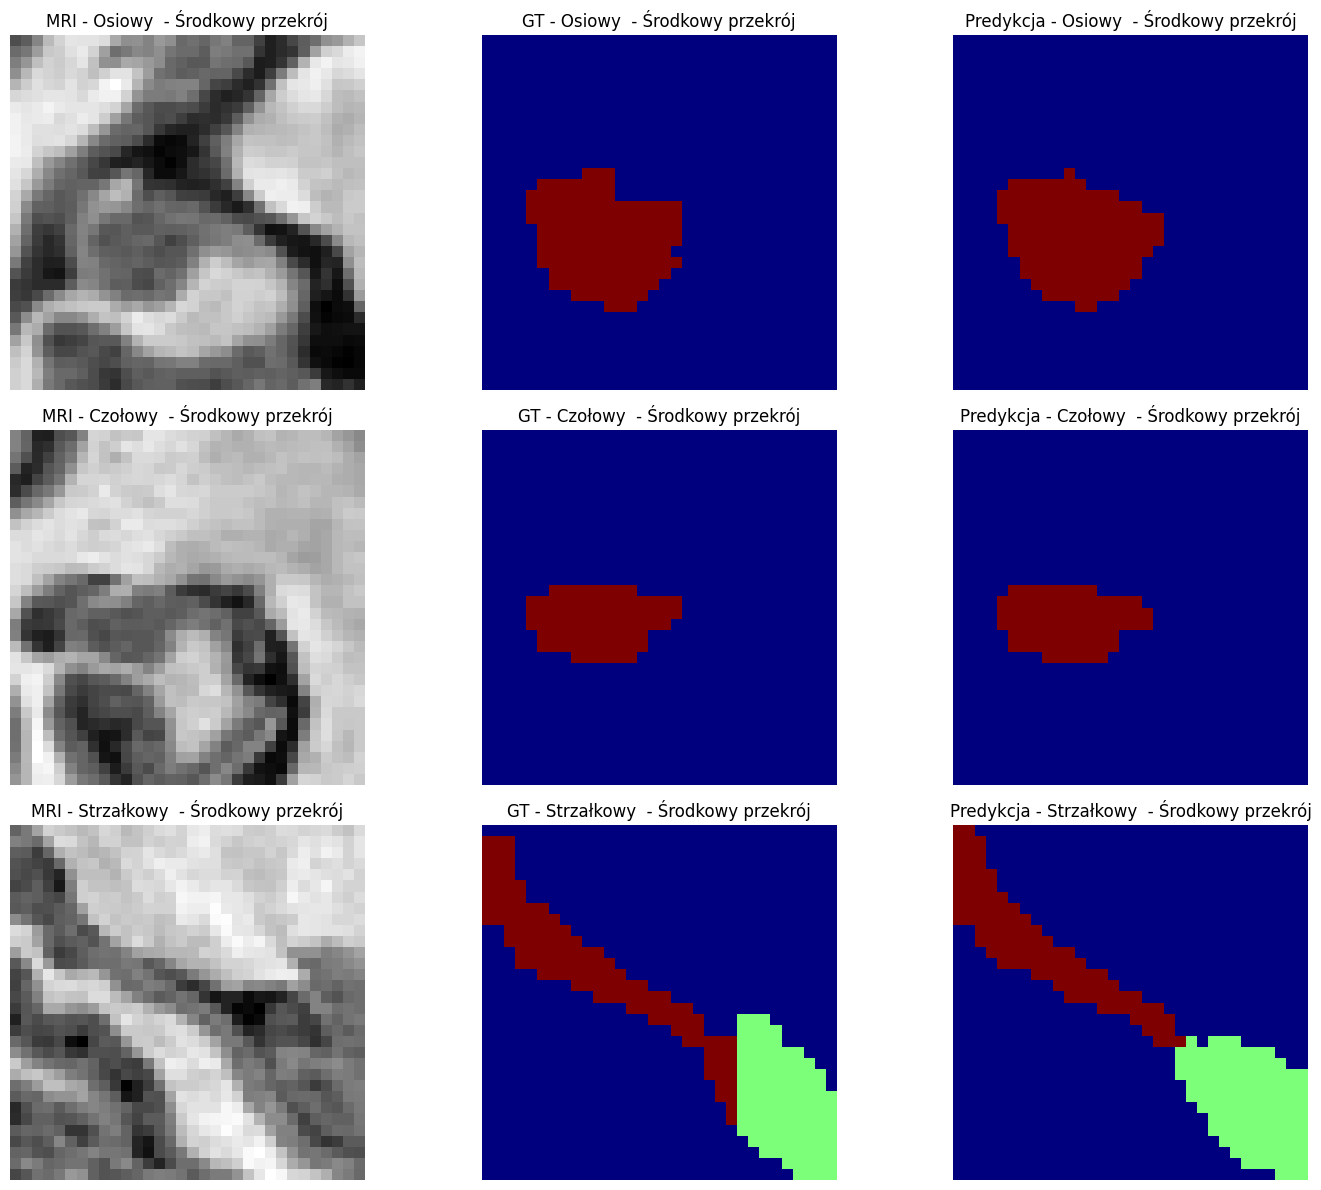


=== METRYKI DLA PRZYPADKU ===
Tło: Dice = 0.9922, IoU = 0.9845
Hipokamp przedni: Dice = 0.8300, IoU = 0.7094
Hipokamp tylny: Dice = 0.8338, IoU = 0.7150
Średni Dice: 0.8853
Średni IoU: 0.8029


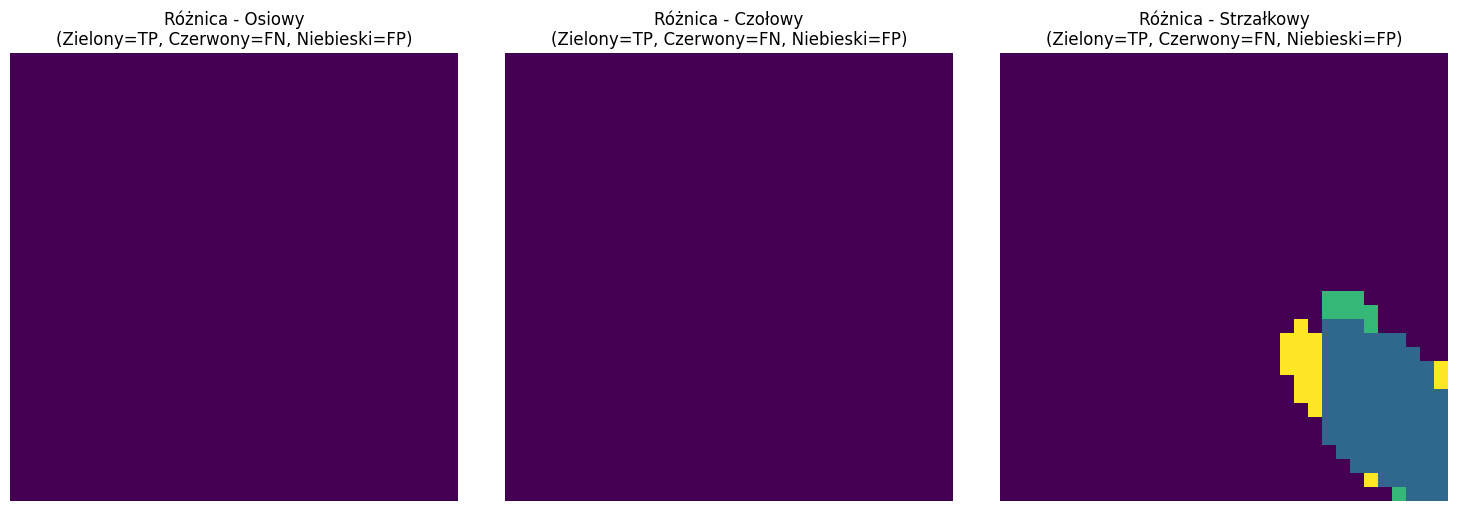

In [12]:
# 1. Przełączenie modelu w tryb ewaluacji i przeniesienie na urządzenie
best_model.eval()
best_model = best_model.to(device)
print(f"Model przeniesiony na urządzenie: {device}")

# 2. Pobranie pierwszego przypadku ze zbioru testowego
case = dm.test_ds[0]
print(f"Rozmiar obrazu: {case['image'].shape}")
print(f"Rozmiar maski: {case['label'].shape}")

# 3. Przygotowanie wolumenu do inferencji
vol = case["image"].unsqueeze(0).to(device)  # Dodanie wymiaru batch i przeniesienie na urządzenie
print(f"Rozmiar wolumenu po przygotowaniu: {vol.shape}")

# 4. Pobranie ground truth
gt = case["label"].squeeze(0).cpu().numpy()
print(f"Rozmiar GT: {gt.shape}")

# 5. Inferencja z sliding window
with torch.no_grad():
    logits = sliding_window_inference(
        inputs=vol,
        roi_size=ROI_SIZE,
        sw_batch_size=BATCH_SIZE,
        predictor=best_model,
        overlap=0.5,
        mode="gaussian"  # Wagi gaussowskie dla gładszego połączenia
    )
    print(f"Rozmiar logitów: {logits.shape}")

# 6. Konwersja logitów na predykcje klas
pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
print(f"Rozmiar predykcji: {pred.shape}")

# 7. Wizualizacja środkowych przekrojów
def plot_three_views(volume, gt_mask, pred_mask, title_suffix=""):
    """
    Rysuje trzy środkowe przekroje (osiowy, czołowy, strzałkowy) dla wolumenu, maski GT i predykcji
    """
    # Znajdowanie środkowych indeksów dla każdej osi
    mid_axial = volume.shape[2] // 2
    mid_coronal = volume.shape[1] // 2
    mid_sagittal = volume.shape[0] // 2
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    # Przekrój osiowy (axial)
    axes[0, 0].imshow(volume[:, :, mid_axial].T, cmap="gray", origin="lower")
    axes[0, 0].set_title(f"MRI - Osiowy {title_suffix}")
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(gt_mask[:, :, mid_axial].T, cmap="jet", origin="lower", vmin=0, vmax=2)
    axes[0, 1].set_title(f"GT - Osiowy {title_suffix}")
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(pred_mask[:, :, mid_axial].T, cmap="jet", origin="lower", vmin=0, vmax=2)
    axes[0, 2].set_title(f"Predykcja - Osiowy {title_suffix}")
    axes[0, 2].axis('off')
    
    # Przekrój czołowy (coronal)
    axes[1, 0].imshow(volume[:, mid_coronal, :].T, cmap="gray", origin="lower")
    axes[1, 0].set_title(f"MRI - Czołowy {title_suffix}")
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(gt_mask[:, mid_coronal, :].T, cmap="jet", origin="lower", vmin=0, vmax=2)
    axes[1, 1].set_title(f"GT - Czołowy {title_suffix}")
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(pred_mask[:, mid_coronal, :].T, cmap="jet", origin="lower", vmin=0, vmax=2)
    axes[1, 2].set_title(f"Predykcja - Czołowy {title_suffix}")
    axes[1, 2].axis('off')
    
    # Przekrój strzałkowy (sagittal)
    axes[2, 0].imshow(volume[mid_sagittal, :, :].T, cmap="gray", origin="lower")
    axes[2, 0].set_title(f"MRI - Strzałkowy {title_suffix}")
    axes[2, 0].axis('off')
    
    axes[2, 1].imshow(gt_mask[mid_sagittal, :, :].T, cmap="jet", origin="lower", vmin=0, vmax=2)
    axes[2, 1].set_title(f"GT - Strzałkowy {title_suffix}")
    axes[2, 1].axis('off')
    
    axes[2, 2].imshow(pred_mask[mid_sagittal, :, :].T, cmap="jet", origin="lower", vmin=0, vmax=2)
    axes[2, 2].set_title(f"Predykcja - Strzałkowy {title_suffix}")
    axes[2, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Przygotowanie danych do wizualizacji
volume_np = case["image"].squeeze(0).cpu().numpy()  # Usunięcie kanału

# Wizualizacja
plot_three_views(volume_np, gt, pred, " - Środkowy przekrój")

# Dodatkowo: obliczenie metryk dla tego przypadku
from monai.metrics import compute_dice, compute_iou

def calculate_case_metrics(gt_mask, pred_mask, num_classes=3):
    """
    Oblicza metryki Dice i IoU dla poszczególnych klas
    """
    dice_scores = []
    iou_scores = []
    
    for class_id in range(num_classes):
        gt_class = (gt_mask == class_id).astype(np.float32)
        pred_class = (pred_mask == class_id).astype(np.float32)
        
        # Dice dla klasy
        if np.sum(gt_class) + np.sum(pred_class) == 0:
            dice = 1.0  # Oba puste
        else:
            dice = 2 * np.sum(gt_class * pred_class) / (np.sum(gt_class) + np.sum(pred_class))
        
        # IoU dla klasy
        intersection = np.sum(gt_class * pred_class)
        union = np.sum(gt_class) + np.sum(pred_class) - intersection
        iou = intersection / union if union > 0 else 1.0
        
        dice_scores.append(dice)
        iou_scores.append(iou)
    
    return dice_scores, iou_scores

# Obliczenie metryk dla tego przypadku
dice_scores, iou_scores = calculate_case_metrics(gt, pred)

print("\n=== METRYKI DLA PRZYPADKU ===")
class_names = ["Tło", "Hipokamp przedni", "Hipokamp tylny"]
for i, (dice, iou) in enumerate(zip(dice_scores, iou_scores)):
    print(f"{class_names[i]}: Dice = {dice:.4f}, IoU = {iou:.4f}")

print(f"Średni Dice: {np.mean(dice_scores):.4f}")
print(f"Średni IoU: {np.mean(iou_scores):.4f}")

# Wizualizacja różnicy między GT a predykcją
diff_mask = np.zeros_like(gt, dtype=np.float32)
diff_mask[(gt == 1) & (pred == 1)] = 1  # TP - zielony
diff_mask[(gt == 1) & (pred != 1)] = 2  # FN - czerwony (brak w predykcji)
diff_mask[(gt != 1) & (pred == 1)] = 3  # FP - niebieski (fałszywie dodatnie)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Przekrój osiowy z różnicami
mid_axial = gt.shape[2] // 2
im0 = axes[0].imshow(diff_mask[:, :, mid_axial].T, cmap="viridis", origin="lower", vmin=0, vmax=3)
axes[0].set_title("Różnica - Osiowy\n(Zielony=TP, Czerwony=FN, Niebieski=FP)")
axes[0].axis('off')

# Przekrój czołowy z różnicami
mid_coronal = gt.shape[1] // 2
axes[1].imshow(diff_mask[:, mid_coronal, :].T, cmap="viridis", origin="lower", vmin=0, vmax=3)
axes[1].set_title("Różnica - Czołowy\n(Zielony=TP, Czerwony=FN, Niebieski=FP)")
axes[1].axis('off')

# Przekrój strzałkowy z różnicami
mid_sagittal = gt.shape[0] // 2
axes[2].imshow(diff_mask[mid_sagittal, :, :].T, cmap="viridis", origin="lower", vmin=0, vmax=3)
axes[2].set_title("Różnica - Strzałkowy\n(Zielony=TP, Czerwony=FN, Niebieski=FP)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

---

## Podsumowanie i wnioski

Odpowiedz krótko na poniższe pytania.

1. Co oznacza ROI_SIZE w przypadku segmentacji 3D jak w wykonanym ćwiczeniu?

ROI_SIZE to rozmiar fragmentów 3D wycinanych z pełnych wolumenów do treningu. Ze względu na ograniczenia pamięci GPU nie przetwarzamy całych skanów MRI na raz, tylko mniejsze kostki 3D (np. 32×32×32 voxeli).

2. Wyjaśnij parametry SAMPLES_PER_VOLUME i POS_NEG_RATIO.

SAMPLES_PER_VOLUME - liczba patchy pobieranych z każdego wolumenu w epoce (zwiększa różnorodność danych). POS_NEG_RATIO - stosunek patchy zawierających obiekt do patchy z samym tłem, co zapobiega przeuczeniu na klasę większościowej (tło).

3. W jaki sposób V-Net różni się od U-Net (np. sposób łączenia ścieżek enkodera/dekodera)?

V-Net używa dodawania połączeń między enkoderem a dekoderem zamiast konkatenacji jak w U-Net. Dodatkowo wykorzystuje bloki rezydualne i konwolucje 3D zamiast 2D.


4. Jak działa sliding_window_inference i jaki wpływ ma parametr overlap na jakość predykcji?

sliding_window_inference dzieli duży wolumen na nakładające się okna, przetwarza je partiami i składa predykcję. Overlap (np. 0.5) zmniejsza artefakty na granicach okien poprzez uśrednianie predykcji w obszarach nakładania, co poprawia płynność i dokładność segmentacji.